In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import torch
import slicetca
from sklearn.cluster import KMeans
from scipy.stats import sem



In [94]:
use_final=True
with h5py.File(filepath, 'r') as f:
    print(f['animals'].keys())

<KeysViewHDF5 ['L', 'Light', 'R', 'Running', 'ShiftL', 'ShiftLight', 'ShiftR', 'ShiftR_zscore', 'ShiftRunning', 'ShiftV', 'V']>


In [2]:
use_final=True
with h5py.File(filepath, 'r') as f:
    if use_final:
        animal_group = f['animals']
    else:
        animal_group = f['animal']

    shiftR_refs = animal_group['ShiftR'][:]

    shiftRunning_refs = animal_group['ShiftRunning'][:]

    animal_clean_dict_activity = {}


    animal_trials_original = []
    animal_trials_clean = []

    count = 0
    for animal_idx in range(len(shiftR_refs)):
        delta_f = np.array(f[shiftR_refs[animal_idx][0]])
        for cell in range(delta_f.shape[0]):
            cell_data = delta_f[cell,:,:]
            nan_mask= np.isnan(cell_data)
            # plt.title(f"cell {count}")
            # plt.imshow(nan_mask, aspect='auto')
            # plt.show()
            count+=1


NameError: name 'filepath' is not defined

In [3]:
print("p")

p


session 0 og:257 new:255
session 1 og:213 new:210
session 2 og:243 new:241
session 3 og:215 new:213
session 4 og:189 new:188
session 5 og:353 new:351
session 6 og:130 new:128
session 7 og:121 new:118
session 8 og:292 new:287
session 9 og:181 new:175
session 10 og:207 new:199
session 11 og:162 new:158
session 12 og:199 new:194
session 13 og:258 new:254
session 14 og:204 new:200
session 15 og:231 new:223
session 16 og:155 new:150
session 17 og:109 new:94
session 18 og:175 new:171
session 19 og:257 new:253
session 20 og:254 new:248
session 21 og:234 new:229
session 22 og:262 new:258
session 23 og:151 new:147
session 24 og:254 new:250
session 25 og:250 new:245
session 26 og:224 new:220
session 27 og:178 new:172
session 28 og:278 new:269
session 29 og:238 new:235
session 30 og:215 new:211
session 31 og:281 new:269
session 32 og:195 new:194
session 33 og:160 new:155
session 34 og:207 new:201
session 35 og:245 new:241
session 36 og:206 new:199
session 37 og:251 new:247
session 38 og:274 new:2

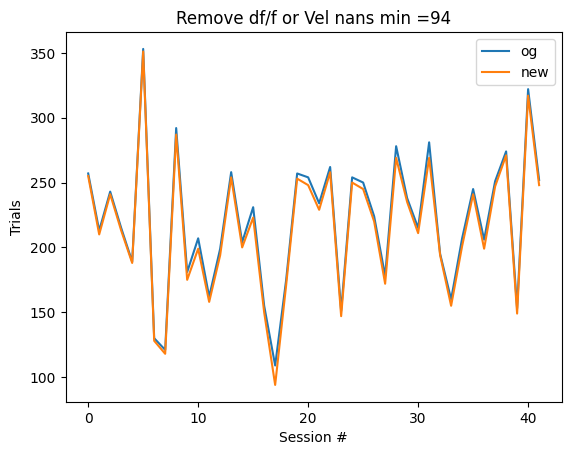

trials to remove cell 105 [0, 1, 2, 3, 179, 180]


In [27]:

filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E0A1B1_251107.mat'



def has_run_of_n_nans(trial_data, n=4):
    
    nan_mask = np.isnan(trial_data)
    if not np.any(nan_mask):
        return False
    
    conv = np.convolve(nan_mask.astype(int), np.ones(n, dtype=int), mode='valid')
    return np.any(conv >= n)


def interp_nans_1d(trial_data):
    x = np.arange(trial_data.size)
    nan_mask = np.isnan(trial_data)

    if not np.any(nan_mask):
        return trial_data

    if not np.any(~nan_mask):  # all NaNs
        return trial_data

    trial_data[nan_mask] = np.interp(x[nan_mask], x[~nan_mask], trial_data[~nan_mask])
    return trial_data



def get_animal_clean_dict_activity(filepath):

    use_final=True
    with h5py.File(filepath, 'r') as f:
        if use_final:
            animal_group = f['animals']
        else:
            animal_group = f['animal']

        shiftR_refs = animal_group['ShiftR'][:]

        shiftRunning_refs = animal_group['ShiftRunning'][:]

        animal_clean_dict_activity = {}


        animal_trials_original = []
        animal_trials_clean = []

        count = 0

        animal_vel_dict = {}

        trials_to_remove_local = []
        for animal_idx in range(len(shiftR_refs)):
            delta_f = np.array(f[shiftR_refs[animal_idx][0]])

            animal_trials_original.append(delta_f.shape[1])


            # nan_trials = np.any(np.isnan(delta_f), axis=(0, 2))

            # delta_f_clean = delta_f[:, ~nan_trials, :]

            # delta_f_clean = delta_f

            vel = f[shiftRunning_refs[animal_idx][0]]

            vel = np.array(vel).T

            # vel_nan_mask = np.isnan(vel)

            # plt.imshow(vel_nan_mask, aspect='auto')
            # plt.title(f"animal_idx {animal_idx} nans={np.any(vel_nan_mask)}")
            # plt.show()


            vel_clean = np.empty(vel.shape)

        
            trials_to_remove_list = []

            delta_f_clean = np.empty(delta_f.shape)


            # print(f"delta_f.shape {delta_f.shape}")

            
            if animal_idx == 22:
                valid_cells = range(1, delta_f.shape[0])
            else:
                valid_cells = range(delta_f.shape[0])

            for cell in valid_cells: #range(delta_f.shape[0]):
                
            
                cell_data = delta_f[cell,:,:].T

                # nan_mask = np.isnan(cell_data)

                # cell_list_num_trials.append(np.sum(nan_mask, axis=0))


                for trial in range(cell_data.shape[1]):

                    trial_data = cell_data[:, trial]

                    vel_data_trial = vel[:,trial]

                    if np.any(np.isnan(trial_data)) or np.any(np.isnan(vel_data_trial)):

                        has_5_nans = has_run_of_n_nans(trial_data, n=5)

                        has_5_nans_vel = has_run_of_n_nans(vel_data_trial, n=5)
                        
                        if has_5_nans or has_5_nans_vel:                            
                            if count == 105:
                                trials_to_remove_local.append(trial)

                            

                            # plt.plot(trial_data)
                            # plt.title(f"Before More than 5 nans cell={count} trial={trial}")
                            # plt.show()

                            # plt.plot(trial_data)
                            # plt.title(f"After More than 5 nans cell={count} trial={trial}")
                            # plt.show()

                            if trial not in trials_to_remove_list:
                                trials_to_remove_list.append(trial)
                        else:

                            # if count==30:

                            #     plt.plot(trial_data)
                            #     plt.title(f"Before Less than 5 nans cell={count} trial={trial}")
                            #     plt.show()

                            trial_data = interp_nans_1d(trial_data)
                            delta_f_clean[cell, trial, :] = trial_data

                            trial_data_vel = interp_nans_1d(vel_data_trial)
                            vel_clean[:,trial] = trial_data_vel




                            # if count==30:
                            #     plt.plot(trial_data)
                            #     plt.title(f"After Less than 5 nans cell={count} trial={trial}")
                            #     plt.show()

                    else:
                        delta_f_clean[cell, trial, :] = trial_data

                        vel_clean[:,trial] = trial_data_vel = vel_data_trial


                count+=1




            trials_to_remove_array = np.array(trials_to_remove_list) 

            if len(trials_to_remove_array) !=0:

                # print(f"trials_to_remove_array {trials_to_remove_array}")
                mask = np.ones(cell_data.shape[1], dtype=bool)
                mask[trials_to_remove_array] = False
                delta_f_clean = delta_f_clean[:, mask,:]

                vel_clean = vel_clean[:, mask]

            animal_trials_clean.append(delta_f_clean.shape[1])

            cell_dict = {}


            for cell in valid_cells:#range(delta_f.shape[0]):

                cell_data = delta_f_clean[cell,:,:]

                cell_data = (cell_data - np.mean(cell_data)) / np.std(cell_data)

                cell_dict[f"cell_{cell+1}"] = cell_data.T
                

            animal_clean_dict_activity[f"animal_{animal_idx+1}"] = cell_dict
            animal_vel_dict[f"animal_{animal_idx+1}"] = vel_clean

        return animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local



animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local = get_animal_clean_dict_activity(filepath)


for i in range(len(animal_trials_original)):
    print(f"session {i} og:{animal_trials_original[i]} new:{animal_trials_clean[i]}")

plt.plot(animal_trials_original, label='og')
plt.plot(animal_trials_clean, label="new")
plt.legend()
plt.xlabel("Session #")
plt.ylabel("Trials")
plt.title(f"Remove df/f or Vel nans min ={np.min(animal_trials_clean)}")
plt.show()

print(f"trials to remove cell 105 {trials_to_remove_local}")

# max_t = 0 

# for cell in range(len(cell_list_num_trials)):
#     current_length = len(cell_list_num_trials[cell]) 

#     if current_length > max_t:
#         max_t = current_length # Update max_t to hold the new maximum length (an integer)

# cell_nan_array = np.full((len(cell_list_num_trials), max_t), np.nan)

# for cell in range(len(cell_list_num_trials)):
#     cell_nan_array[cell, :len(cell_list_num_trials[cell])] = cell_list_num_trials[cell]


# plt.imshow(cell_nan_array, aspect='auto')
# plt.title("Sum Over Pos Bins Nans Per Trial")
# plt.ylabel("Cell ID")
# plt.xlabel("Trial")
# plt.colorbar()
# plt.show()

        

clean_fixed_activity_dict_NDNF_newest = {}

clean_fixed_velocity_dict_NDNF_newest = {}

for idx, animal in enumerate(animal_clean_dict_activity):
    if 14 < idx < 29:
        clean_fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_clean_dict_activity[animal]
        clean_fixed_velocity_dict_NDNF_newest[f"animal_{idx+1}"] = {"Velocity":animal_vel_dict[animal]}

cued_clean_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(animal_clean_dict_activity):
    if idx > 28:
        cued_clean_activity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_clean_dict_activity[animal]



In [4]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV


In [14]:
def fit_GLM(animal_factors_dict, neuron_activity, regression='linear', alphas=None):
    neuron_activity_flat = neuron_activity.flatten()
    flattened_data = flatten_data(animal_factors_dict)
    variable_names = [var for var in flattened_data]
    design_matrix_X = np.stack([flattened_data[var] for var in variable_names], axis=1)

    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    neuron_predicted_activity = model.predict(design_matrix_X)

    trialavg_neuron_activity = np.mean(neuron_activity, axis=1)
    trialavg_predicted_activity = np.mean(neuron_predicted_activity.reshape(neuron_activity.shape), axis=1)
    pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0, 1]
    neuron_GLM_params = {}
    neuron_GLM_params['weights'] = {var: model.coef_[idx] for idx, var in enumerate(variable_names)}
    neuron_GLM_params['intercept'] = model.intercept_
    neuron_GLM_params['alpha'] = model.alpha_ if regression == 'ridge' else None
    neuron_GLM_params['l1_ratio'] = model.l1_ratio_ if regression == 'elastic' else None
    neuron_GLM_params['R2'] = model.score(design_matrix_X, neuron_activity_flat)
    neuron_GLM_params['pearson_R'] = pearson_R
    neuron_GLM_params['model'] = model
    return neuron_GLM_params, neuron_predicted_activity

def get_residual_activity_dict(activity_dict, predicted_activity_dict):
    residual_activity_dict = {}
    for animal in activity_dict:
        residual_activity_dict[animal] = {}
        for neuron in activity_dict[animal]:
            residual_activity_dict[animal][neuron] = activity_dict[animal][neuron] - predicted_activity_dict[animal][neuron]
    return residual_activity_dict

def flatten_data(neuron_dict):
    flattened_data = {}
    for var in neuron_dict:
        flattened_data[var] = neuron_dict[var].flatten()
    return flattened_data

def fit_GLM_population(factors_dict, activity_dict, quintile=None, regression='ridge', alphas=None):
    GLM_params = {}
    predicted_activity_dict = {}

    for animal in factors_dict:
        GLM_params[animal] = {}
        predicted_activity_dict[animal] = {}
        animal_factors_dict = factors_dict[animal].copy()

        if quintile is not None:
            num_trials = animal_factors_dict['Activity'].shape[1]
            start_idx, end_idx = get_quintile_indices(num_trials, quintile)
            for var in animal_factors_dict:
                animal_factors_dict[var] = animal_factors_dict[var][:, start_idx:end_idx]

        for neuron_idx in activity_dict[animal]:
            neuron_activity = activity_dict[animal][neuron_idx]
            neuron_GLM_params, neuron_predicted_activity = fit_GLM(animal_factors_dict, neuron_activity, regression, alphas)
            GLM_params[animal][neuron_idx] = neuron_GLM_params
            predicted_activity_dict[animal][neuron_idx] = neuron_predicted_activity.reshape(activity_dict[animal][neuron_idx].shape)
                
    return GLM_params, predicted_activity_dict

In [6]:
GLM_params, predicted_activity_dict = fit_GLM_population_new(clean_fixed_velocity_dict_NDNF_newest, clean_fixed_activity_dict_NDNF_newest, quintile=None, regression='ridge', alphas=None)

In [9]:
def get_real_animal_tensor(residual_activity_dict_SST, animal_num=1):
    real_animal_activity = residual_activity_dict_SST[f'animal_{animal_num+29}']
    real_animal_data_list = []
    for neuron in real_animal_activity:
        cell_activity = real_animal_activity[neuron]
        real_animal_data_list.append(cell_activity)
    animal_tensor = np.array(real_animal_data_list)
    animal_tensor = animal_tensor.transpose(2, 0, 1)
    
    return animal_tensor

from scipy.spatial.distance import cdist

def enforce_min_cluster_size(labels, X, min_trials=3, max_passes=2, verbose=False):
    """
    Post-process k-means labels to ensure each cluster has at least min_trials samples.
    Reassigns members of small clusters to the nearest 'big' cluster by Euclidean distance in X.
    Optionally iterates (max_passes) because reassignments change cluster sizes.

    Parameters
    ----------
    labels : (n_samples,) int array
    X      : (n_samples, n_feats) array used for clustering (here: f1)
    min_trials : int, minimum cluster size
    max_passes : int, do a couple passes to stabilize
    verbose    : bool

    Returns
    -------
    new_labels : (n_samples,) int array with no small clusters
    kept_map   : dict old_label -> new_label (only for surviving clusters)
    """
    labels = np.asarray(labels).copy()
    for _ in range(max_passes):
        # sizes per label
        uniq, counts = np.unique(labels, return_counts=True)
        small = set(uniq[counts < min_trials])
        big   = [u for u,c in zip(uniq, counts) if c >= min_trials]

        if verbose:
            print(f"[min-size pass] big={big}, small={sorted(small)}")

        if not small:
            break

        # centroids for current labels
        centroids = {}
        for u in uniq:
            centroids[u] = X[labels == u].mean(axis=0)

        # reassign every sample from small clusters to nearest big centroid
        big_centroid_mat = np.vstack([centroids[b] for b in big]) if big else None
        for u in list(small):
            mask = (labels == u)
            if not big:
                # corner case: everything is small; just put all in one cluster
                labels[mask] = 0
                continue
            d = cdist(X[mask], big_centroid_mat)  # (n_small, n_big)
            nn = d.argmin(axis=1)
            labels[mask] = np.array(big, dtype=int)[nn]

        # continue to next pass; sizes will be updated in next loop

    # compress labels to 0..K'-1
    uniq = np.unique(labels)
    remap = {u:i for i,u in enumerate(uniq)}
    new_labels = np.array([remap[u] for u in labels], dtype=int)

    kept_map = {u: remap[u] for u in uniq}
    return new_labels, kept_map


def get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(EC_model_dict_00x_cell, residual_activity_dict_SST, max_clusters=12, display=True, use_changepoint=False):

    MSE_mean_clusters = []
    MSE_sem_clusters = []
    X_f1_dict = {}
    labels_dict = {}
    indices_for_cluster_number_dict = {}
    TCA_reconstructions_dict = {}
    Recon_by_cluster_av_dict = {}
    cluster_trial_mean_dict = {}

    for clusters_chosen in range(2, max_clusters):

        animal_MSE_list = []
        animal_X_f1_dict = {}
        animal_labels_dict = {}
        animal_indices_for_cluster_number = {}
        animal_TCA_reconstructions_dict = {}
        animal_Recon_by_cluster_av_dict = {}
        animal_cluster_trial_mean_dict = {}

        for animal_id, animal in enumerate(EC_model_dict_00x_cell):

            animal_id = animal_id +1

            cell_MSE_list = []
            cell_X_f1_dict = {}
            cell_labels_dict = {}
            cell_indices_for_cluster_number = {}
            cell_TCA_reconstructions_dict = {}
            cell_Recon_by_cluster_av_dict = {}
            cell_cluster_trial_mean_dict = {}

            for cell_id, cell in enumerate(EC_model_dict_00x_cell[animal]):

                model = EC_model_dict_00x_cell[animal][cell]

            # for model in EC_model_dict_00x_cell[animal]:
                reconstruction_cell = model.construct().numpy(force=True)
                cell_TCA_reconstructions_dict[f"cell_{cell_id}"] = reconstruction_cell


                f = model.vectors[2][1].detach()
                f1 = f.permute(2, 0, 1)  # [5, 40, 212]

                f1 = f1.reshape(-1, f1.shape[-1]).T  # [200, 212]
                
                if use_changepoint:
                    # f1_model = f1.f1(n_components=3, random_state=0)
                    # X_f1 = f1_model.fit_transform(f1)  #(trials,3)

                    algo = rpt.Binseg(model="l2", min_size=5).fit(f1)
                    bkps = algo.predict(n_bkps=clusters_chosen-1)

                    labels = np.zeros(f1.shape[0], dtype=int)
                    start = 0
                    for cluster_id, end in enumerate(bkps):
                        labels[start:end] = cluster_id
                        start = end

                else:
                    print(f"f1.shape {f1.shape}")
                    kmeans = KMeans(n_clusters=clusters_chosen, random_state=0)
                    labels = kmeans.fit_predict(f1)

                min_trials = 3  # your criterion
                labels, kept_map = enforce_min_cluster_size(labels, f1, min_trials=min_trials, max_passes=2, verbose=False)


                cell_X_f1_dict[f"cell_{cell_id}"] = f1
                cell_labels_dict[f"cell_{cell_id}"] = labels

#                 mean_cluster_trials = []
                animal_tensor = get_real_animal_tensor(residual_activity_dict_SST, animal_id)
                neuron_activity = animal_tensor[:,cell_id,:]

                valid_cluster_mean_trials_list = []
                valid_cluster_indices = []
                for n in range(clusters_chosen):
                    trial_indices = np.where(labels == n)[0]

                    if len(trial_indices) > 2:

                        cluster_trials = reconstruction_cell[trial_indices, 0, :]  # shape (num_trials, time)


                        mean_cluster = cluster_trials.mean(axis=0)
                        valid_cluster_mean_trials_list.append(mean_cluster)

                        valid_cluster_indices.append((n, trial_indices))

                    else:
                        print(f"Skipping cluster {n} (only {len(trial_indices)} trials)")
                cell_cluster_trial_mean_dict[f"cell_{cell_id}"] = valid_cluster_mean_trials_list
                cluster_trial_indices = {n: np.where(labels == n)[0] for n in range(clusters_chosen)}
                cell_indices_for_cluster_number[f"cell_{cell_id}"] = cluster_trial_indices


                empty_cell = np.zeros(neuron_activity.shape)

                for i, (n, trials) in enumerate(valid_cluster_indices):
                    empty_cell[trials,:] = valid_cluster_mean_trials_list[i]
                cell_Recon_by_cluster_av_dict[f"cell_{cell_id}"] = empty_cell

                neuron_MSE = np.mean(np.square(neuron_activity - empty_cell))

                cell_MSE_list.append(neuron_MSE)

            mean_cell_MSE = np.mean(cell_MSE_list)
            animal_MSE_list.append(mean_cell_MSE)

            animal_X_f1_dict[animal] = cell_X_f1_dict
            animal_labels_dict[animal] = cell_labels_dict
            animal_indices_for_cluster_number[animal] = cell_indices_for_cluster_number
            animal_TCA_reconstructions_dict[animal] = cell_TCA_reconstructions_dict
            animal_Recon_by_cluster_av_dict[animal] = cell_Recon_by_cluster_av_dict
            animal_cluster_trial_mean_dict[animal] = cell_cluster_trial_mean_dict

            
        animal_MSE_array = np.array(animal_MSE_list)
        print(f"animal_MSE_array.shape {animal_MSE_array.shape}")
        
        MSE_mean_clusters.append(np.mean(animal_MSE_array))
        MSE_sem_clusters.append(sem(animal_MSE_array))
        
        X_f1_dict[f"clusters_{clusters_chosen}"] = animal_X_f1_dict
        labels_dict[f"clusters_{clusters_chosen}"] = animal_labels_dict
        indices_for_cluster_number_dict[f"clusters_{clusters_chosen}"] = animal_indices_for_cluster_number
        TCA_reconstructions_dict[f"clusters_{clusters_chosen}"] = animal_TCA_reconstructions_dict
        Recon_by_cluster_av_dict[f"clusters_{clusters_chosen}"] = animal_Recon_by_cluster_av_dict
        cluster_trial_mean_dict[f"clusters_{clusters_chosen}"] = animal_cluster_trial_mean_dict
        
        
    print(f"len(MSE_mean_clusters) {len(MSE_mean_clusters)}")


    internals_dict = {
        
        "X_f1_dict" : X_f1_dict,
        "labels_dict" : labels_dict,
        "indices_for_cluster_number_dict" : indices_for_cluster_number_dict,
        "TCA_reconstructions_dict" : TCA_reconstructions_dict,
        "Recon_by_cluster_av_dict" : Recon_by_cluster_av_dict,
        "cluster_trial_mean_dict" : cluster_trial_mean_dict,
        "MSE_mean_clusters":MSE_mean_clusters}

    return MSE_mean_clusters, MSE_sem_clusters, internals_dict

In [8]:
clean_fixed_velocity_dict_NDNF_newest.keys()

dict_keys(['animal_16', 'animal_17', 'animal_18', 'animal_19', 'animal_20', 'animal_21', 'animal_22', 'animal_23', 'animal_24', 'animal_25', 'animal_26', 'animal_27', 'animal_28', 'animal_29'])

In [25]:

def get_cell_cell_model_dict(clean_fixed_activity_dict_NDNF_newest, components=None):
    cell_by_cell_tca_model_dict = {}

    for animal in clean_fixed_activity_dict_NDNF_newest:
        cell_dict = {}
        for cell in clean_fixed_activity_dict_NDNF_newest[animal]:
            data = clean_fixed_activity_dict_NDNF_newest[animal][cell]
            data_tensor = torch.from_numpy(data.T).float()   # (trials, pos_bins) = (223, 50)
            data_tensor = data_tensor.unsqueeze(1)           # (trials, 1, 50)
            print(data_tensor.shape)                         # torch.Size([223, 1, 50])

            components20, model_20 = slicetca.decompose(data_tensor,
                                                        number_components=components, # (trials, neurons, time bins)
                                                        positive=False,learning_rate=1*10**-2, min_std=10**-5, max_iter=4000, iter_std=1000,seed=0)
            
            cell_dict[cell] = model_20
        cell_by_cell_tca_model_dict[animal] = cell_dict

    return cell_by_cell_tca_model_dict

cell_by_cell_tca_model_dict = get_cell_cell_model_dict(clean_fixed_activity_dict_NDNF_newest, components=(20,0,0))

# print(len(data_tensor_liat))

torch.Size([223, 1, 50])


Loss: 0.040639396756887436 : 100%|██████████| 4000/4000 [00:24<00:00, 160.53it/s]


torch.Size([223, 1, 50])


Loss: 0.040639396756887436 : 100%|██████████| 4000/4000 [00:28<00:00, 138.18it/s]


torch.Size([223, 1, 50])


...

Loss: 0.040310751646757126 : 100%|██████████| 4000/4000 [00:37<00:00, 105.56it/s]


torch.Size([269, 1, 50])


Loss: 0.08013290911912918 : 100%|██████████| 4000/4000 [00:37<00:00, 107.50it/s]


torch.Size([269, 1, 50])


Loss: 0.17319899797439575 : 100%|██████████| 4000/4000 [00:38<00:00, 104.09it/s]


In [ ]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_contig_models_NDNF.pkl', 'wb') as f:
    pickle.dump(fixed_contig_dict_final_x00, f)

'/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/ndnf_cell_types'

In [34]:


def get_real_animal_tensor(residual_activity_dict_SST, animal_num=1):
    real_animal_activity = residual_activity_dict_SST[f'animal_{animal_num+29}']
    real_animal_data_list = []
    for neuron in real_animal_activity:
        cell_activity = real_animal_activity[neuron]
        real_animal_data_list.append(cell_activity)
    animal_tensor = np.array(real_animal_data_list)
    animal_tensor = animal_tensor.transpose(2, 0, 1)
    
    return animal_tensor

from scipy.spatial.distance import cdist

def enforce_min_cluster_size(labels, X, min_trials=3, max_passes=2, verbose=False):
    """
    Post-process k-means labels to ensure each cluster has at least min_trials samples.
    Reassigns members of small clusters to the nearest 'big' cluster by Euclidean distance in X.
    Optionally iterates (max_passes) because reassignments change cluster sizes.

    Parameters
    ----------
    labels : (n_samples,) int array
    X      : (n_samples, n_feats) array used for clustering (here: f1)
    min_trials : int, minimum cluster size
    max_passes : int, do a couple passes to stabilize
    verbose    : bool

    Returns
    -------
    new_labels : (n_samples,) int array with no small clusters
    kept_map   : dict old_label -> new_label (only for surviving clusters)
    """
    labels = np.asarray(labels).copy()
    for _ in range(max_passes):
        # sizes per label
        uniq, counts = np.unique(labels, return_counts=True)
        small = set(uniq[counts < min_trials])
        big   = [u for u,c in zip(uniq, counts) if c >= min_trials]

        if verbose:
            print(f"[min-size pass] big={big}, small={sorted(small)}")

        if not small:
            break

        # centroids for current labels
        centroids = {}
        for u in uniq:
            centroids[u] = X[labels == u].mean(axis=0)

        # reassign every sample from small clusters to nearest big centroid
        big_centroid_mat = np.vstack([centroids[b] for b in big]) if big else None
        for u in list(small):
            mask = (labels == u)
            if not big:
                # corner case: everything is small; just put all in one cluster
                labels[mask] = 0
                continue
            d = cdist(X[mask], big_centroid_mat)  # (n_small, n_big)
            nn = d.argmin(axis=1)
            labels[mask] = np.array(big, dtype=int)[nn]

        # continue to next pass; sizes will be updated in next loop

    # compress labels to 0..K'-1
    uniq = np.unique(labels)
    remap = {u:i for i,u in enumerate(uniq)}
    new_labels = np.array([remap[u] for u in labels], dtype=int)

    kept_map = {u: remap[u] for u in uniq}
    return new_labels, kept_map


def get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(EC_model_dict_00x_cell, residual_activity_dict_SST, max_clusters=12, display=True, use_changepoint=False):

    MSE_mean_clusters = []
    MSE_sem_clusters = []
    X_f1_dict = {}
    labels_dict = {}
    indices_for_cluster_number_dict = {}
    TCA_reconstructions_dict = {}
    Recon_by_cluster_av_dict = {}
    cluster_trial_mean_dict = {}

    for clusters_chosen in range(2, max_clusters):

        animal_MSE_list = []
        animal_X_f1_dict = {}
        animal_labels_dict = {}
        animal_indices_for_cluster_number = {}
        animal_TCA_reconstructions_dict = {}
        animal_Recon_by_cluster_av_dict = {}
        animal_cluster_trial_mean_dict = {}

        for animal_id, animal in enumerate(EC_model_dict_00x_cell):

            animal_id = animal_id +1

            cell_MSE_list = []
            cell_X_f1_dict = {}
            cell_labels_dict = {}
            cell_indices_for_cluster_number = {}
            cell_TCA_reconstructions_dict = {}
            cell_Recon_by_cluster_av_dict = {}
            cell_cluster_trial_mean_dict = {}

            for cell_id, cell in enumerate(EC_model_dict_00x_cell[animal]):

                model = EC_model_dict_00x_cell[animal][cell]

            # for model in EC_model_dict_00x_cell[animal]:
                reconstruction_cell = model.construct().numpy(force=True)
                cell_TCA_reconstructions_dict[f"cell_{cell_id}"] = reconstruction_cell


                f = model.vectors[2][1].detach()
                f1 = f.permute(2, 0, 1)  # [5, 40, 212]

                f1 = f1.reshape(-1, f1.shape[-1]).T  # [200, 212]
                
                if use_changepoint:
                    # f1_model = f1.f1(n_components=3, random_state=0)
                    # X_f1 = f1_model.fit_transform(f1)  #(trials,3)

                    algo = rpt.Binseg(model="l2", min_size=5).fit(f1)
                    bkps = algo.predict(n_bkps=clusters_chosen-1)

                    labels = np.zeros(f1.shape[0], dtype=int)
                    start = 0
                    for cluster_id, end in enumerate(bkps):
                        labels[start:end] = cluster_id
                        start = end

                else:
                    print(f"f1.shape {f1.shape}")
                    kmeans = KMeans(n_clusters=clusters_chosen, random_state=0)
                    labels = kmeans.fit_predict(f1)

                min_trials = 3  # your criterion
                labels, kept_map = enforce_min_cluster_size(labels, f1, min_trials=min_trials, max_passes=2, verbose=False)


                cell_X_f1_dict[f"cell_{cell_id}"] = f1
                cell_labels_dict[f"cell_{cell_id}"] = labels

#                 mean_cluster_trials = []
                animal_tensor = get_real_animal_tensor(residual_activity_dict_SST, animal_id)
                neuron_activity = animal_tensor[:,cell_id,:]

                valid_cluster_mean_trials_list = []
                valid_cluster_indices = []
                for n in range(clusters_chosen):
                    trial_indices = np.where(labels == n)[0]

                    if len(trial_indices) > 2:

                        cluster_trials = reconstruction_cell[trial_indices, 0, :]  # shape (num_trials, time)


                        mean_cluster = cluster_trials.mean(axis=0)
                        valid_cluster_mean_trials_list.append(mean_cluster)

                        valid_cluster_indices.append((n, trial_indices))

                    else:
                        print(f"Skipping cluster {n} (only {len(trial_indices)} trials)")
                cell_cluster_trial_mean_dict[f"cell_{cell_id}"] = valid_cluster_mean_trials_list
                cluster_trial_indices = {n: np.where(labels == n)[0] for n in range(clusters_chosen)}
                cell_indices_for_cluster_number[f"cell_{cell_id}"] = cluster_trial_indices


                empty_cell = np.zeros(neuron_activity.shape)

                for i, (n, trials) in enumerate(valid_cluster_indices):
                    empty_cell[trials,:] = valid_cluster_mean_trials_list[i]
                cell_Recon_by_cluster_av_dict[f"cell_{cell_id}"] = empty_cell

                neuron_MSE = np.mean(np.square(neuron_activity - empty_cell))

                cell_MSE_list.append(neuron_MSE)

            mean_cell_MSE = np.mean(cell_MSE_list)
            animal_MSE_list.append(mean_cell_MSE)

            animal_X_f1_dict[animal] = cell_X_f1_dict
            animal_labels_dict[animal] = cell_labels_dict
            animal_indices_for_cluster_number[animal] = cell_indices_for_cluster_number
            animal_TCA_reconstructions_dict[animal] = cell_TCA_reconstructions_dict
            animal_Recon_by_cluster_av_dict[animal] = cell_Recon_by_cluster_av_dict
            animal_cluster_trial_mean_dict[animal] = cell_cluster_trial_mean_dict

            
        animal_MSE_array = np.array(animal_MSE_list)
        print(f"animal_MSE_array.shape {animal_MSE_array.shape}")
        
        MSE_mean_clusters.append(np.mean(animal_MSE_array))
        MSE_sem_clusters.append(sem(animal_MSE_array))
        
        X_f1_dict[f"clusters_{clusters_chosen}"] = animal_X_f1_dict
        labels_dict[f"clusters_{clusters_chosen}"] = animal_labels_dict
        indices_for_cluster_number_dict[f"clusters_{clusters_chosen}"] = animal_indices_for_cluster_number
        TCA_reconstructions_dict[f"clusters_{clusters_chosen}"] = animal_TCA_reconstructions_dict
        Recon_by_cluster_av_dict[f"clusters_{clusters_chosen}"] = animal_Recon_by_cluster_av_dict
        cluster_trial_mean_dict[f"clusters_{clusters_chosen}"] = animal_cluster_trial_mean_dict
        
        
    print(f"len(MSE_mean_clusters) {len(MSE_mean_clusters)}")


    internals_dict = {
        
        "X_f1_dict" : X_f1_dict,
        "labels_dict" : labels_dict,
        "indices_for_cluster_number_dict" : indices_for_cluster_number_dict,
        "TCA_reconstructions_dict" : TCA_reconstructions_dict,
        "Recon_by_cluster_av_dict" : Recon_by_cluster_av_dict,
        "cluster_trial_mean_dict" : cluster_trial_mean_dict,}

    return MSE_mean_clusters, MSE_sem_clusters, internals_dict




import re

def repackage_labels_to_rank_animal_cell_model(
    internals_dict,
    model_lookup,                  # <-- REQUIRED: same [animal][cell] structure holding your models
    rank_key=20,
    clusters_src_prefix="clusters_",
    clusters_dst_prefix="clusters_chosen_",
):
    """
    Build:
      out[rank_key][animal][cell] = [ model, { f'cell_{cell}': { 'labels_dict': {...} } } ]

    Where the labels_dict aggregates all cluster sizes from internals_dict['labels_dict'].
    """

    def _get_model(animal, cell_idx):
        """
        Try several key styles to fetch the model from model_lookup.
        """
        if animal not in model_lookup:
            return None
        # direct int key
        if cell_idx in model_lookup[animal]:
            return model_lookup[animal][cell_idx]
        # 'cell_<idx>' key
        ck = f"cell_{cell_idx}"
        if ck in model_lookup[animal]:
            return model_lookup[animal][ck]
        # fallback: if keys are strings of ints
        if str(cell_idx) in model_lookup[animal]:
            return model_lookup[animal][str(cell_idx)]
        # if model_lookup[animal] is a list/tuple indexed by int
        try:
            return model_lookup[animal][cell_idx]
        except Exception:
            return None

    labels_root = internals_dict.get("labels_dict", {})
    out = {rank_key: {}}

    # We'll accumulate per (animal, cell) and attach the model once per cell
    # Structure we are building for the second list element:
    #   {'cell_<idx>': {'labels_dict': {'clusters_chosen_<k>': labels_arr, ...}}}
    acc = {}  # (animal, cell_idx) -> {'cell_<idx>': {'labels_dict': {...}}}

    for clusters_key, animal_map in labels_root.items():
        # parse k from "clusters_2"
        m = re.match(rf"{re.escape(clusters_src_prefix)}(\d+)$", clusters_key)
        if not m:
            continue
        k = int(m.group(1))
        dst_key = f"{clusters_dst_prefix}{k}"

        for animal, cells_dict in animal_map.items():
            out[rank_key].setdefault(animal, {})
            for cell_key, labels_arr in cells_dict.items():
                mcell = re.match(r"cell_(\d+)$", str(cell_key))
                cell_idx = int(mcell.group(1)) if mcell else (int(cell_key) if str(cell_key).isdigit() else cell_key)
                acc_key = (animal, cell_idx)

                # init the labels container for this cell if needed
                if acc_key not in acc:
                    acc[acc_key] = {f"cell_{cell_idx}": {"labels_dict": {}}}

                acc[acc_key][f"cell_{cell_idx}"]["labels_dict"][dst_key] = labels_arr

    # Now assemble the final structure: [model, labels_dict_struct]
    for (animal, cell_idx), labels_struct in acc.items():
        model_obj = _get_model(animal, cell_idx)
        out[rank_key].setdefault(animal, {})
        out[rank_key][animal][cell_idx] = [model_obj, labels_struct]

    return out



In [40]:
NDNF_fixed_model_dict_clean = {}
for idx, animal in enumerate(NDNF_fixed_model_dict):
    cell_dict = {}
    for idt, cell in enumerate(NDNF_fixed_model_dict[animal]):
        cell_dict[idt] = NDNF_fixed_model_dict[animal][cell]
    NDNF_fixed_model_dict_clean[idx] = cell_dict

NDNF_fixed_model_dict_clean[1].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [41]:

# save_path = '/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/ndnf_cell_types/single_cell_sliceTCA_more_trials_fixed.pkl'
# with open(save_path, 'rb') as f:
#     NDNF_fixed_model_dict = pickle.load(f)

MSE_mean_clusters_NDNF_cell_00x_f1_kmeans, MSE_sem_clusters_NDNF_cell_00x_f1_kmeans, internals_dict_NDNF_cell_00x_f1_regkmean_reassign = get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(NDNF_fixed_model_dict_clean, clean_fixed_activity_dict_NDNF_newest, max_clusters=8, display=False, use_changepoint=False)


fixed_kmean_dict_final_x00 = repackage_labels_to_rank_animal_cell_model(
    internals_dict_NDNF_cell_00x_f1_regkmean_reassign,
    model_lookup=NDNF_fixed_model_dict,   # <- your per-animal, per-cell models
    rank_key=20,
    clusters_src_prefix="clusters_",
    clusters_dst_prefix="clusters_chosen_",)




f1.shape torch.Size([223, 0])


ValueError: Found array with 0 feature(s) (shape=(223, 0)) while a minimum of 1 is required by KMeans.

In [47]:


def preprocess_animal(NDNF_fixed_model_dict, residual_activity_dict, num_clusters=8, reassign_clusters=False, x00=True, umap=True, contiguous=True, ranks=20):
    # tensor_list_by_animal_all_SST = []
    # for animal in residual_activity_dict:
    #     neural_data = ut.get_animal_neural_tensor(residual_activity_dict, animal=animal)
    #     neural_data_tensor = torch.tensor(neural_data)
    #     # Normalize per cell
    #     for i in range(neural_data_tensor.shape[1]):
    #         cell = neural_data_tensor[:, i, :]
    #         min_val = cell.min()
    #         max_val = cell.max()
    #         neural_data_tensor[:, i, :] = (cell - min_val) / (max_val - min_val + 1e-8)
    #     tensor_list_by_animal_all_SST.append(neural_data_tensor)


    internals_per_animal_dict_EC_animal_x00_regkmean = {}
    
    for idx, animal in enumerate(residual_activity_dict):
        internals_per_animal_dict_EC_animal_x00_regkmean_cell = {}
        for idt, cell in enumerate(residual_activity_dict[animal]):

            cell_data = residual_activity_dict[animal][cell].T
            cell_data = ((cell_data-np.min(cell_data)) / np.max(cell_data) - np.min(cell_data))
            cell_data_3d = np.expand_dims(cell_data, axis=1)
            cell_data_3d = torch.from_numpy(cell_data_3d)
            cell_model = NDNF_fixed_model_dict[idx][idt]


    # internals_per_animal_dict_EC_animal_x00_regkmean = {}
    # for animal in animal_EC_model_ranks20_contig_x00[ranks]:
    #     animal_model = animal_EC_model_ranks20_contig_x00[ranks][animal][0]
        # tensor_for_animal = tensor_list_by_animal_all_SST[animal]
            internals_dict = get_animal_model_reconstruction_dict_mod(cell_model, cell_data_3d, max_clusters=num_clusters, display=False, reassign_small_clusters=reassign_clusters, x00=x00, use_umap=umap, use_breakpoints=contiguous)

            internals_per_animal_dict_EC_animal_x00_regkmean_cell[idt] = internals_dict
        
        internals_per_animal_dict_EC_animal_x00_regkmean[idx] = internals_per_animal_dict_EC_animal_x00_regkmean_cell

    return internals_per_animal_dict_EC_animal_x00_regkmean


def get_animal_model_reconstruction_dict_mod(animal_model, tensor_for_animal, max_clusters=12, display=False, reassign_small_clusters=True, x00=True, use_umap=False, use_breakpoints=False):
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    per_cell_internals_dict = {}
    reconstruction_full_animal = animal_model.construct().numpy(force=True)

    if x00:
        w1 = animal_model.vectors[0][0].detach().numpy()
        X = np.abs(w1.T)
        if use_umap:
            import umap
            umap_model = umap.UMAP(n_components=3, random_state=0)
            X_umap = umap_model.fit_transform(X)
    else:
        f = animal_model.vectors[2][1].detach()
        f1 = f.permute(1, 0, 2).reshape(f.shape[1], -1)
        f1 = torch.abs(f1).cpu().numpy()
        if use_umap:
            import umap
            umap_model = umap.UMAP(n_components=3, random_state=0)
            X_umap = umap_model.fit_transform(f1)

    cluster_labels_dict = {}
    cluster_pca_dict = {}
    cluster_centroids_dict = {}

    for clusters_chosen in range(1, max_clusters):
        if use_breakpoints:
            print(f"Using breakpoint clustering (clusters = {clusters_chosen})")
            model_input = X_umap if use_umap else (X if x00 else f1)
            n_bkps = clusters_chosen - 1
            algo = rpt.Binseg(model="l2", min_size=3).fit(model_input)
            try:
                bkps = algo.predict(n_bkps=n_bkps)
            except rpt.exceptions.BadSegmentationParameters:
                print("  Skipping due to bad breakpoint config")
                continue

            labels = np.zeros(model_input.shape[0], dtype=int)
            start = 0
            for cluster_id, end in enumerate(bkps):
                labels[start:end] = cluster_id
                start = end

            centroids = np.array([
                model_input[labels == i].mean(axis=0)
                for i in range(clusters_chosen)
            ])
            X_pca = PCA(n_components=3).fit_transform(model_input)

        else:
            kmeans = KMeans(n_clusters=clusters_chosen, random_state=0)
            model_input = X_umap if use_umap else (X if x00 else f1)
            labels = kmeans.fit_predict(model_input)

            centroids = kmeans.cluster_centers_
            if use_umap:
                X_pca = PCA(n_components=3).fit_transform(X_umap)
            else:
                X_pca = PCA(n_components=3).fit_transform(model_input)

        cluster_labels_dict[clusters_chosen] = labels
        cluster_centroids_dict[clusters_chosen] = centroids
        cluster_pca_dict[clusters_chosen] = X_pca

    for cell in range(reconstruction_full_animal.shape[1]):
        #     cell = 0
        print(f"Processing cell {cell}...")

        MSE_dict = {}
        x_pca_dict = {}
        labels_dict = {}
        indices_for_cluster_number = {}
        TCA_reconstructions_dict = {}
        Recon_by_cluster_av_dict = {}
        cluster_trial_mean_dict = {}

        reconstructed_cell = reconstruction_full_animal[:, cell, :]
        real_cell_activity = tensor_for_animal[:, cell, :].detach().numpy()

        for clusters_chosen in range(1, max_clusters):
            labels = cluster_labels_dict[clusters_chosen].copy()
            centroids = cluster_centroids_dict[clusters_chosen]
            X_pca = cluster_pca_dict[clusters_chosen]
            model_input = X_umap if use_umap else (X if x00 else f1)

            print(f"\nclusters_chosen = {clusters_chosen}")
            print("Before reassignment:")
            for cluster_id in range(clusters_chosen):
                count = np.sum(labels == cluster_id)
                print(f"  Cluster {cluster_id}: {count} trials")

            if reassign_small_clusters:
                if use_umap:
                    model_input = X_umap
                    centroid_space = np.array([
                        model_input[labels == i].mean(axis=0)
                        for i in range(clusters_chosen)])
                else:
                    model_input = X if x00 else f1
                    centroid_space = centroids
                for cluster_id in range(clusters_chosen):
                    trial_indices = np.where(labels == cluster_id)[0]
                    if len(trial_indices) < 2:
                        print(f"  Reassigning cluster {cluster_id} (size={len(trial_indices)})...")
                        for idx in trial_indices:
                            trial = model_input[idx]
                            dists = cdist([trial], centroid_space)[0]
                            dists[cluster_id] = np.inf
                            new_cluster = np.argmin(dists)
                            labels[idx] = new_cluster

            print("After reassignment:")
            for cluster_id in range(clusters_chosen):
                count = np.sum(labels == cluster_id)
                print(f"  Cluster {cluster_id}: {count} trials")

            x_pca_dict[f"clusters_chosen_{clusters_chosen}"] = X_pca
            labels_dict[f"clusters_chosen_{clusters_chosen}"] = labels

            valid_cluster_mean_trials_list = []
            valid_cluster_indices = []
            cluster_trial_indices = {}

            for n in range(clusters_chosen):
                trial_indices = np.where(labels == n)[0]
                cluster_trial_indices[n] = trial_indices
                if len(trial_indices) == 0:
                    continue
                cluster_trials = real_cell_activity[trial_indices, :]
                mean_cluster = cluster_trials.mean(axis=0)
                valid_cluster_mean_trials_list.append(mean_cluster)
                valid_cluster_indices.append((n, trial_indices))

            empty_cell = np.zeros_like(reconstructed_cell)
            for i, (n, trials) in enumerate(valid_cluster_indices):
                empty_cell[trials, :] = valid_cluster_mean_trials_list[i]

            key = f"clusters_chosen_{clusters_chosen}"
            MSE_dict[key] = np.mean((real_cell_activity - empty_cell) ** 2)
            Recon_by_cluster_av_dict[key] = empty_cell
            TCA_reconstructions_dict[key] = reconstructed_cell
            cluster_trial_mean_dict[key] = valid_cluster_mean_trials_list
            indices_for_cluster_number[key] = cluster_trial_indices

        per_cell_internals_dict[f"cell_{cell}"] = {
            "MSE_dict": MSE_dict,
            "x_pca_dict": x_pca_dict,
            "labels_dict": labels_dict,
            "indices_for_cluster_number": indices_for_cluster_number,
            "TCA_reconstructions_dict": TCA_reconstructions_dict,
            "Recon_by_cluster_av_dict": Recon_by_cluster_av_dict,
            "cluster_trial_mean_dict": cluster_trial_mean_dict,
        }

    return per_cell_internals_dict

testing_data = preprocess_animal(NDNF_fixed_model_dict_clean, clean_fixed_activity_dict_NDNF_newest, num_clusters=8, reassign_clusters=True, x00=True, umap=False, contiguous=False, ranks=20)

Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 223 trials
After reassignment:
  Cluster 0: 223 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 183 trials
  Cluster 1: 40 trials
After reassignment:
  Cluster 0: 183 trials
  Cluster 1: 40 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 71 trials
  Cluster 1: 22 trials
  Cluster 2: 130 trials
After reassignment:
  Cluster 0: 71 trials
  Cluster 1: 22 trials
  Cluster 2: 130 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 79 trials
  Cluster 1: 7 trials
  Cluster 2: 117 trials
  Cluster 3: 20 trials
After reassignment:
  Cluster 0: 79 trials
  Cluster 1: 7 trials
  Cluster 2: 117 trials
  Cluster 3: 20 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 77 trials
  Cluster 1: 6 trials
  Cluster 2: 119 trials
  Cluster 3: 20 trials
  Cluster 4: 1 trials
  Reassigning cluster 4 (size=1)...
After reassignment:
  Cluster 0: 77 trials
  Cluster 1: 7 trials
  Cluste

In [48]:
fixed_reassign_dict = preprocess_animal(NDNF_fixed_model_dict_clean, clean_fixed_activity_dict_NDNF_newest, num_clusters=8, reassign_clusters=True, x00=True, umap=False, contiguous=False, ranks=20)

Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 223 trials
After reassignment:
  Cluster 0: 223 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 183 trials
  Cluster 1: 40 trials
After reassignment:
  Cluster 0: 183 trials
  Cluster 1: 40 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 71 trials
  Cluster 1: 22 trials
  Cluster 2: 130 trials
After reassignment:
  Cluster 0: 71 trials
  Cluster 1: 22 trials
  Cluster 2: 130 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 79 trials
  Cluster 1: 7 trials
  Cluster 2: 117 trials
  Cluster 3: 20 trials
After reassignment:
  Cluster 0: 79 trials
  Cluster 1: 7 trials
  Cluster 2: 117 trials
  Cluster 3: 20 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 77 trials
  Cluster 1: 6 trials
  Cluster 2: 119 trials
  Cluster 3: 20 trials
  Cluster 4: 1 trials
  Reassigning cluster 4 (size=1)...
After reassignment:
  Cluster 0: 77 trials
  Cluster 1: 7 trials
  Cluste

In [57]:
fixed_contig_dict = preprocess_animal(NDNF_fixed_model_dict_clean, clean_fixed_activity_dict_NDNF_newest, num_clusters=5, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)

Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using breakpoint clustering (clusters = 3)
Using breakpoint clustering (clusters = 4)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 223 trials
After reassignment:
  Cluster 0: 223 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 140 trials
  Cluster 1: 83 trials
After reassignment:
  Cluster 0: 140 trials
  Cluster 1: 83 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 140 trials
  Cluster 1: 50 trials
  Cluster 2: 33 trials
After reassignment:
  Cluster 0: 140 trials
  Cluster 1: 50 trials
  Cluster 2: 33 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 140 trials
  Cluster 1: 40 trials
  Cluster 2: 10 trials
  Cluster 3: 33 trials
After reassignment:
  Cluster 0: 140 trials
  Cluster 1: 40 trials
  Cluster 2: 10 trials
  Cluster 3: 33 trials
Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using

In [50]:
NDNF_cued_model_dict_clean = {}
for idx, animal in enumerate(cued_cell_by_cell_tca_model_dict):
    cell_dict = {}
    for idt, cell in enumerate(cued_cell_by_cell_tca_model_dict[animal]):
        cell_dict[idt] = cued_cell_by_cell_tca_model_dict[animal][cell]
    NDNF_cued_model_dict_clean[idx] = cell_dict

NDNF_cued_model_dict_clean[1].keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [55]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_cued_model_dict_clean.pkl', 'wb') as f:
    pickle.dump(NDNF_cued_model_dict_clean, f)

In [56]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_fixed_model_dict_clean.pkl', 'wb') as f:
    pickle.dump(NDNF_fixed_model_dict_clean, f)

In [51]:
cued_reassign_dict = preprocess_animal(NDNF_cued_model_dict_clean, cued_clean_activity_dict_NDNF_newest, num_clusters=8, reassign_clusters=True, x00=True, umap=False, contiguous=False, ranks=20)

Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 235 trials
After reassignment:
  Cluster 0: 235 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 184 trials
  Cluster 1: 51 trials
After reassignment:
  Cluster 0: 184 trials
  Cluster 1: 51 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 117 trials
  Cluster 1: 73 trials
  Cluster 2: 45 trials
After reassignment:
  Cluster 0: 117 trials
  Cluster 1: 73 trials
  Cluster 2: 45 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 55 trials
  Cluster 1: 112 trials
  Cluster 2: 37 trials
  Cluster 3: 31 trials
After reassignment:
  Cluster 0: 55 trials
  Cluster 1: 112 trials
  Cluster 2: 37 trials
  Cluster 3: 31 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 53 trials
  Cluster 1: 90 trials
  Cluster 2: 11 trials
  Cluster 3: 22 trials
  Cluster 4: 59 trials
After reassignment:
  Cluster 0: 53 trials
  Cluster 1: 90 trials
  Cluster 2: 11 trials
  Cluster 3: 22 t

In [ ]:
cued_contig_dict[0][0]["cell_0"].keys()

dict_keys(['MSE_dict', 'x_pca_dict', 'labels_dict', 'indices_for_cluster_number', 'TCA_reconstructions_dict', 'Recon_by_cluster_av_dict', 'cluster_trial_mean_dict'])

In [ ]:
cued_contig_final = {20:{}}

for animal in cued_contig_dict:
    cell_dict = {}
    for cell in cued_contig_dict[animal]:
        cell_dict[cell] = cued_contig_dict[animal][cell][f"cell_{cell}"][0,]

In [ ]:
def reshape_contig_dict(cued_contig_dict, NDNF_cued_model_dict_clean):
    cued_contig_final = {20: {}}  # rank 20 as top-level key

    for animal in cued_contig_dict:  # animal is e.g. 0, 1, 2...
        cued_contig_final[20][animal] = {}

        for cell in cued_contig_dict[animal]:  # cell is e.g. 0, 1, 2...
            # 1) SliceTCA model for this animal/cell
            model_obj = NDNF_cued_model_dict_clean[animal][cell]

            # 2) Internals dict for this animal/cell (already has "cell_0" inside)
            per_cell_internals = cued_contig_dict[animal][cell][f"cell_{cell}"]

            # 3) Match the old structure: [model, per_cell_internals]
            cued_contig_final[20][animal][cell] = [model_obj, per_cell_internals]

    return cued_contig_final


cued_contig_final = reshape_contig_dict(fixed_contig_dict, NDNF_fixed_model_dict_clean)


# cued_contig_final = reshape_contig_dict(cued_contig_dict, NDNF_cued_model_dict_clean)


In [72]:

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict


changepoints_dict = get_cp_dict(cued_contig_final)

KeyError: 'cell_1'

In [79]:
cued_contig_final[20][1][5][1].keys()

dict_keys(['cell_0'])

In [63]:
contig_dict_all_cell_tca = preprocess_animal(NDNF_fixed_model_dict_clean, clean_fixed_activity_dict_NDNF_newest, num_clusters=5, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)


Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using breakpoint clustering (clusters = 3)
Using breakpoint clustering (clusters = 4)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 223 trials
After reassignment:
  Cluster 0: 223 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 140 trials
  Cluster 1: 83 trials
After reassignment:
  Cluster 0: 140 trials
  Cluster 1: 83 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 140 trials
  Cluster 1: 50 trials
  Cluster 2: 33 trials
After reassignment:
  Cluster 0: 140 trials
  Cluster 1: 50 trials
  Cluster 2: 33 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 140 trials
  Cluster 1: 40 trials
  Cluster 2: 10 trials
  Cluster 3: 33 trials
After reassignment:
  Cluster 0: 140 trials
  Cluster 1: 40 trials
  Cluster 2: 10 trials
  Cluster 3: 33 trials
Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using

In [54]:
cued_contig_dict = preprocess_animal(NDNF_cued_model_dict_clean, cued_clean_activity_dict_NDNF_newest, num_clusters=5, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)

Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using breakpoint clustering (clusters = 3)
Using breakpoint clustering (clusters = 4)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 235 trials
After reassignment:
  Cluster 0: 235 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 85 trials
  Cluster 1: 150 trials
After reassignment:
  Cluster 0: 85 trials
  Cluster 1: 150 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 50 trials
  Cluster 1: 35 trials
  Cluster 2: 150 trials
After reassignment:
  Cluster 0: 50 trials
  Cluster 1: 35 trials
  Cluster 2: 150 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 50 trials
  Cluster 1: 35 trials
  Cluster 2: 55 trials
  Cluster 3: 95 trials
After reassignment:
  Cluster 0: 50 trials
  Cluster 1: 35 trials
  Cluster 2: 55 trials
  Cluster 3: 95 trials
Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using b

In [53]:
from sklearn.decomposition import PCA
import ruptures as rpt


In [28]:

cued_cell_by_cell_tca_model_dict = get_cell_cell_model_dict(cued_clean_activity_dict_NDNF_newest, components=(20,0,0))

torch.Size([235, 1, 50])


Loss: 0.04400607571005821 : 100%|██████████| 4000/4000 [00:28<00:00, 141.09it/s] 


torch.Size([235, 1, 50])


Loss: 0.04400607571005821 : 100%|██████████| 4000/4000 [00:24<00:00, 162.54it/s] 


torch.Size([235, 1, 50])


...

Loss: 0.16439878940582275 : 100%|██████████| 4000/4000 [00:38<00:00, 103.26it/s]


torch.Size([248, 1, 50])


Loss: 0.1519879549741745 : 100%|██████████| 4000/4000 [00:37<00:00, 105.43it/s] 


torch.Size([248, 1, 50])


Loss: 0.15385492146015167 : 100%|██████████| 4000/4000 [00:37<00:00, 108.02it/s]


In [33]:
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/ndnf_cell_types/single_cell_sliceTCA_more_trials_cued.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(cued_cell_by_cell_tca_model_dict, f)

In [15]:


def get_the_tca_model_every_cell(clean_fixed_velocity_dict_NDNF_newest, clean_fixed_activity_dict_NDNF_newest, components=None):

    GLM_params, predicted_activity_dict = fit_GLM_population(clean_fixed_velocity_dict_NDNF_newest, clean_fixed_activity_dict_NDNF_newest, quintile=None, regression='ridge', alphas=None)

    residual_activity_dict_NDNF_new = get_residual_activity_dict(clean_fixed_activity_dict_NDNF_newest, predicted_activity_dict)

    data_truncated_array_fix_resid, min_val = get_truncated_to_min_data_array(residual_activity_dict_NDNF_new)

    example_cells_tensor = torch.from_numpy(data_truncated_array_fix_resid)
        
    example_cells_tensor = example_cells_tensor.permute(2,0,1)

    cells_model_dict

    for cell in example_cell_tensor.shape[1]:

        example_cell_tensor = example_cells_tensor[:,cell,:]

        print(f"example_cell_tensor.shape {example_cell_tensor.shape}")
        
        # components, model_20 = slicetca.decompose(example_cell_tensor,
        #                                             number_components=components, # (trials, neurons, time bins)
        #                                             positive=False,learning_rate=1*10**-2, min_std=10**-5, max_iter=4000, iter_std=1000,seed=0)

        # plt.plot(model_20.losses, color='k')
        # plt.show()

    return model_20, example_cell_tensor

model_20_raw_new_activity_alll_cells_dict, example_cell_tensor = get_the_tca_model_every_cell(clean_fixed_velocity_dict_NDNF_newest, clean_fixed_activity_dict_NDNF_newest, components=(0,20,0))

NameError: name 'get_truncated_to_min_data_array' is not defined

In [82]:
def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
    min_val = 10000

    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data = fixed_activity_dict_NDNF_newest[animal][cell]
            if data.shape[1] < min_val:
                min_val = data.shape[1]

    data_truncated_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            data_truncated_list.append(data_truncated)


    data_truncated_array = np.array(data_truncated_list)

    return data_truncated_array, min_val

def get_mean_behav_factor_per_cell(residual_activity_dict, factors_dict, min_num_trials, factor:str):

    data_list = []
    for animal in residual_activity_dict:
        for cell in residual_activity_dict[animal]:
            data_list.append(factors_dict[animal][factor][:, :min_num_trials])

    return data_list


torch.Size([94, 174, 50])


  0%|          | 0/4000 [00:00<?, ?it/s]

Loss: 0.4826192336875212 : 100%|██████████| 4000/4000 [04:11<00:00, 15.91it/s] 


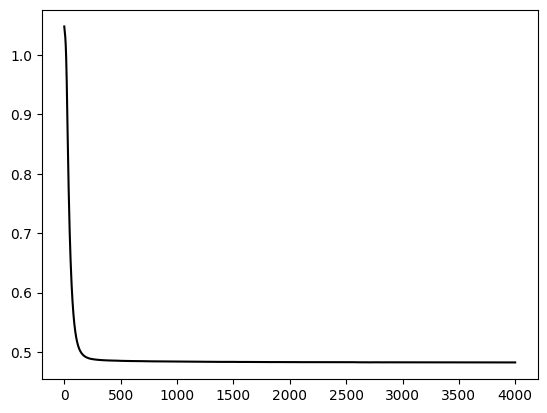

In [83]:
def get_the_tca_model(fixed_residual_activity_dict, components=None):
    data_truncated_array, min_val = get_truncated_to_min_data_array(fixed_residual_activity_dict)
    example_cell_tensor = torch.from_numpy(data_truncated_array)
    example_cell_tensor = example_cell_tensor.permute(2,0,1)

    print(example_cell_tensor.shape)
        
    components, model_20 = slicetca.decompose(example_cell_tensor,
                                                number_components=components, # (trials, neurons, time bins)
                                                positive=False,learning_rate=1*10**-2, min_std=10**-5, max_iter=4000, iter_std=1000,seed=0)

    plt.plot(model_20.losses, color='k')
    plt.show()

    return model_20, example_cell_tensor

model_20_raw_new_activity, example_cell_tensor = get_the_tca_model(clean_fixed_activity_dict_NDNF_newest, components=(0,20,0))


In [ ]:

save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_fixed_model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(model_20_raw_new_activity, f)

In [88]:
torch.any(torch.isnan(example_cell_tensor))
# Create a boolean mask where True indicates a NaN value
nan_mask = torch.isnan(example_cell_tensor)

# Sum the True values in the mask to get the total count
nan_count = torch.sum(nan_mask)

# Convert the resulting single-element tensor to a Python integer
total_nans = nan_count.item()

print(f"The total number of NaNs in the tensor is: {total_nans}")


The total number of NaNs in the tensor is: 0


In [89]:
from sklearn.preprocessing import StandardScaler


def plot_reconstructions(labels_list, fixed_activity_dict_NDNF_newest, prefix="", plot=False):


    synthetic_mean_array = {}
    means_dict_cluster= {}
    for num_clusters in labels_list:
    # for num_clusters in range(len(labels_list)):
        data_truncated_array_NDNF, _ = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
        labels = labels_list[num_clusters]
        uniq = np.unique(labels)
        real_data_mean_array = np.empty(data_truncated_array_NDNF.shape)
        mean_data_dict = {}

        r_vel_dict_per_clust = {}
        r_lick_dict_per_clust = {}

        cell_ids_per_cluster_dict = {}

        vel_data_sliced_dict = {}
        lick_data_sliced_dict = {}

        # vel_array = r_dict_vel["array_data"]
        # lick_array = r_dict_licks["array_data"]

        labels_loc_dict = {}

        mean_data_list = []
        fraction_cells_list = []
        for i in uniq:
            labels_loc = np.where(labels==i)[0]
            cell_ids_per_cluster_dict[i] = labels_loc
            fraction_cells = (len(labels_loc) / data_truncated_array_NDNF.shape[0])*100
            fraction_cells_list.append(fraction_cells)
            real_data_array_sliced = data_truncated_array_NDNF[labels_loc,:,:]
            mean_real_data_array_sliced = np.mean(real_data_array_sliced, axis=0)
            mean_data_list.append(mean_real_data_array_sliced)
            real_data_mean_array[labels_loc,:,:] = mean_real_data_array_sliced

            labels_loc_dict[i] = labels_loc
            
            # r_list_vel = np.array(r_dict_vel["r_list"])

            # r_list_licks = np.array(r_dict_licks["r_list"])

            

            # vel_data_sliced_dict[i] = vel_array[labels_loc,:,:]

            # lick_data_sliced_dict[i] = lick_array[labels_loc,:,:]

            # r_vel_dict_per_clust[i] = r_list_vel[labels_loc]
            # r_lick_dict_per_clust[i] = r_list_licks[labels_loc]



        MSE_reco_vs_real = np.mean(np.square(data_truncated_array_NDNF-real_data_mean_array))

        mean_data_dict = {"mean_data_list":mean_data_list,
                        "fraction_cells":fraction_cells_list,
                        "MSE_reco_vs_real":MSE_reco_vs_real,
                        # "r_vel_dict_per_clust":r_vel_dict_per_clust,
                        # "r_lick_dict_per_clust":r_lick_dict_per_clust,
                        "cell_ids_per_cluster_dict":cell_ids_per_cluster_dict,
                        # "vel_data_sliced_dict":vel_data_sliced_dict,
                        # "lick_data_sliced_dict":lick_data_sliced_dict,
                        "labels_loc_dict":labels_loc_dict}
        
        means_dict_cluster[num_clusters] = mean_data_dict
        synthetic_mean_array[num_clusters] = real_data_mean_array



    data_truncated_array_NDNF, _ = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
    data_truncated_array_NDNF_ta = np.mean(data_truncated_array_NDNF, axis=2),
    if plot:
        fig, axs = plt.subplots(2,len(synthetic_mean_array), figsize=(30,8))
        plt.suptitle(f"Reconstructed vs Real Trial Averaged Data {prefix}")
        for num_clusters in synthetic_mean_array:
            reconstructed_data = synthetic_mean_array[num_clusters]
            reconstructed_data_ta = np.mean(reconstructed_data, axis=2)
            axs[0,num_clusters-1].imshow(reconstructed_data_ta, aspect='auto')
            axs[0,num_clusters-1].set_ylabel("Cell ID")
            axs[0,num_clusters-1].set_title(f"Reconstructed K={num_clusters}")
            axs[0,num_clusters-1].set_xlabel("Position Bin")
            axs[1,num_clusters-1].imshow(data_truncated_array_NDNF_ta, aspect='auto')
            axs[1,num_clusters-1].set_title("Real T.A. Data")
            axs[1,num_clusters-1].set_xlabel("Position Bin")
        plt.tight_layout()
        plt.show()

    return means_dict_cluster

# def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, num_trials, data_to_corr=None):

#     r_list_vel = []
#     vel_per_animal = []
#     for animal in fixed_activity_dict_NDNF_newest:
#         for cell in fixed_activity_dict_NDNF_newest[animal]:
#             vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:num_trials]
#             vel_per_animal.append(vel)
#             data = fixed_activity_dict_NDNF_newest[animal][cell][:,:num_trials]
#             r, _ = pearsonr(vel.flatten(), data.flatten())
#             r_list_vel.append(r)

#     array_data = np.array(vel_per_animal)
#     r_dict_vel = {"r_list":r_list_vel,
#                   "array_data":array_data}

#     return r_dict_vel



# r_dict_vel = get_r_list(clean_fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, example_cell_tensor.shape[0], data_to_corr=None)
# r_dict_licks = get_r_list(clean_fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, example_cell_tensor.shape[0], data_to_corr=None)



def get_labels_all_different_Ks_single(model_20_NDNF_resid, which_vectors: int):

    w1 = model_20_NDNF_resid.vectors[which_vectors][0]
    f1 = model_20_NDNF_resid.vectors[which_vectors][1]
    F = f1.detach().cpu().numpy()   # (latents, cells, pos) = (20, 115, 50)
    W = w1.detach().cpu().numpy()   # (latents, trials) = (20, 100)

    print(f"F.shape {F.shape}  W.shape {W.shape}")

    # Build X so rows = cells (115)
    if which_vectors == 0:
        # Use latent×pos per cell, flattened: (115, 20*50)
        X = np.moveaxis(F, 1, 0)              # (cells=115, latents=20, pos=50)
        X = X.reshape(X.shape[0], -1)         # (115, 1000)
        print("X shape (latent×pos flat):", X.shape)

    elif which_vectors == 1:
        X = W.T  # (115, 20) mean over pos
        print("X shape (mean over pos):", X.shape)

    else:
        X = np.moveaxis(F, 2, 0)     # -> (cells=115, latents=20, trials=100)
        X = X.reshape(X.shape[0], -1)  # -> (115, 20*100) = (115, 2000)
        print(X.shape)  # (115, 2000)

    Xz = StandardScaler().fit_transform(X)
    labels_cells_dict_all_K = {K: KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(Xz) for K in range(1, 11)}
    return labels_cells_dict_all_K


# activity_early_array, activity_array_late = get_activity_cut_learn(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
# plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw NDNF Clustered Changepoint")

In [90]:

def plot_cluster_traces_by_animal(
    means_dict_cluster,                 # output from plot_reconstructions (has cell_ids_per_cluster_dict)
    fixed_activity_dict_NDNF_newest,    # to recompute TA traces
    cells_per_animal_dict,              # {animal: [global_cell_ids...]}
    K, ncol=None,                                  # which K to plot
    ylim=(-1.1, 2.6), spacing=None,  
    title_prefix=""
):
    # --- build cell_id -> animal map ---
    cell_to_animal = {}
    for animal, cell_ids in cells_per_animal_dict.items():
        for cid in cell_ids:
            cell_to_animal[cid] = animal

    # --- get TA data (cells × pos) ---
    data, min_val = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)  # (cells, pos, trials)
    ta = data.mean(axis=2)                                                   # (cells, pos)
    n_cells, n_pos = ta.shape

    # --- clusters & subplot layout ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]      # {cluster_label: array(cell_ids)}
    uniq = sorted(clust_idx_dict.keys())
    label_to_col = {lab: j for j, lab in enumerate(uniq)}

    # --- color map per animal ---
    animals = sorted(set(cell_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    fig, axs = plt.subplots(1, len(uniq), figsize=(4*len(uniq), 6), sharey=True)
    if len(uniq) == 1:
        axs = np.array([axs])

    for lab in uniq:
        ax = axs[label_to_col[lab]]
        idx = np.asarray(clust_idx_dict[lab])
        traces = ta[idx]                                   # (n_k, n_pos)

        # plot each cell trace colored by its animal
        for cid in idx:
            a = cell_to_animal.get(int(cid), "unknown")
            color = animal_to_color.get(a, (0.5,0.5,0.5,0.6))
            ax.plot(traces[np.where(idx==cid)[0][0], :], lw=1.0, alpha=0.7, color=color)

        # overlay mean ± SEM (neutral color)
        m = traces.mean(axis=0)
        s = sem(traces, axis=0) if traces.shape[0] > 1 else np.zeros_like(m)
        ax.plot(m, lw=2.0, color="k")
        ax.fill_between(np.arange(n_pos), m - s, m + s, alpha=0.15, color="k")

        ax.set_title(f"Cluster {lab} (n={len(idx)})")
        ax.set_xlabel("Position bins")
        ax.set_ylim(*ylim)
    axs[0].set_ylabel("Z-scored dF/F")
    fig.suptitle(f"{title_prefix} Traces colored by animal — K={K}", y=1.02, fontsize=12)

    # legend outside: one entry per animal
    handles = [plt.Line2D([0],[0], color=animal_to_color[a], lw=2) for a in animals]
    labels = [f"{a}" for a in animals]
    fig.legend(handles, labels, loc="lower center", ncol=ncol, frameon=False)
    fig.subplots_adjust(top=0.85, right=0.98, left=0.07, bottom=spacing)
    plt.show()


In [91]:

def plot_cluster_animal_composition_stacked(means_dict_cluster, cells_per_animal_dict, K,
                                            title_prefix="", show_percent_labels=False):
    # --- build cell_id -> animal map ---
    cell_to_animal = {}
    for animal, cell_ids in cells_per_animal_dict.items():
        for cid in cell_ids:
            cell_to_animal[int(cid)] = animal

    # --- cluster membership dict for this K ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]  # {cluster_label: array(cell_ids)}
    clusters = sorted(clust_idx_dict.keys())  # keep order stable

    # --- all animals & consistent colors ---
    animals = sorted(set(cell_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    # --- counts matrix: rows=clusters, cols=animals ---
    counts = np.zeros((len(clusters), len(animals)), dtype=int)
    for r, clab in enumerate(clusters):
        for cid in clust_idx_dict[clab]:
            a = cell_to_animal.get(int(cid), None)
            if a is not None:
                c = animals.index(a)
                counts[r, c] += 1

    totals = counts.sum(axis=1)  # cells per cluster

    # --- plot stacked bars (height = counts, stacked by animal) ---
    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(1.2*len(clusters)+3, 5))
    bottom = np.zeros_like(totals, dtype=float)

    bars = []
    for j, a in enumerate(animals):
        b = ax.bar(x, counts[:, j], bottom=bottom, width=0.8,
                   color=animal_to_color[a], label=f"{a}")
        bars.append(b)
        bottom += counts[:, j]

    # x-ticks as cluster labels with n
    ax.set_xticks(x, [f"C{clab}\n(n={totals[i]})" for i, clab in enumerate(clusters)])
    ax.set_ylabel("# cells")
    ax.set_title(f"{title_prefix} K={K}")

    # optional % labels inside segments
    if show_percent_labels:
        with np.errstate(divide='ignore', invalid='ignore'):
            props = counts / totals[:, None]
            props[np.isnan(props)] = 0.0
        for i in range(len(clusters)):
            cum = 0.0
            for j in range(len(animals)):
                h = counts[i, j]
                if h > 0 and props[i, j] >= 0.07:  # only label if ≥7% to avoid clutter
                    ax.text(x[i], cum + h/2.0, f"{props[i, j]*100:.0f}%",
                            ha="center", va="center", fontsize=8, color="white")
                cum += h

    # legend outside
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

def get_cells_per_animal_dict(fixed_activity_dict_NDNF_newest):
    cells_per_animal_dict = {}

    count=0
    for animal in fixed_activity_dict_NDNF_newest:
        per_animal_list=[]
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            per_animal_list.append(count)
            count+=1
        cells_per_animal_dict[animal] = per_animal_list

    return cells_per_animal_dict


In [92]:
print(example_cell_tensor.shape)

torch.Size([94, 174, 50])


F.shape (20, 94, 50)  W.shape (20, 174)
X shape (mean over pos): (174, 20)


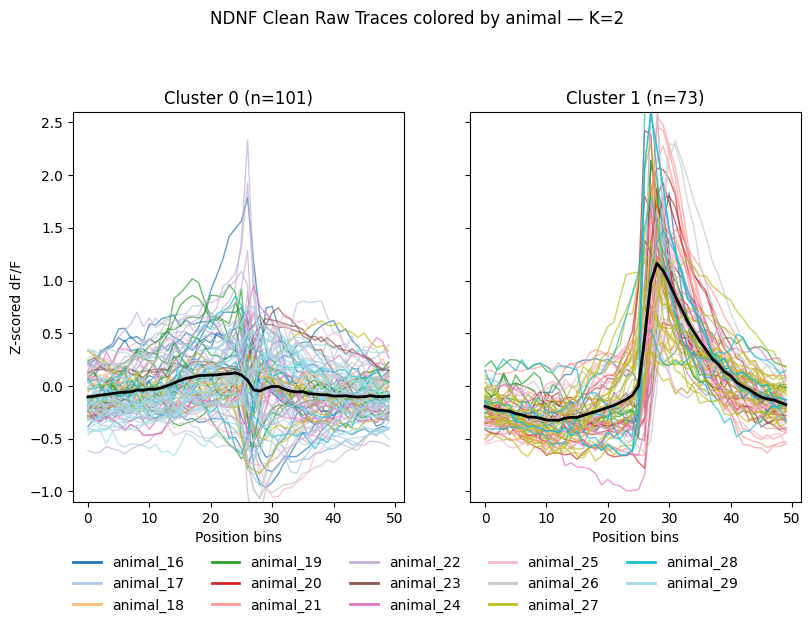

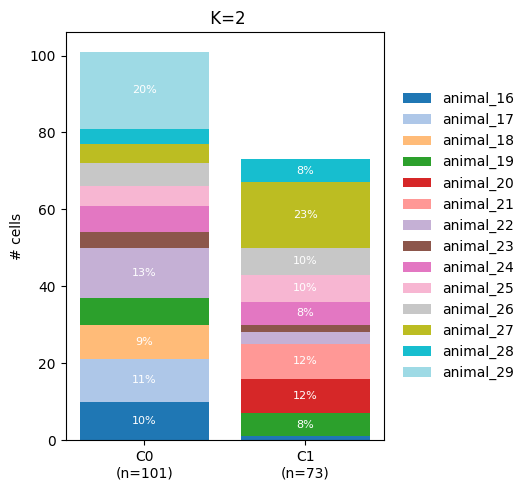

In [93]:


K=2


labels_dict_raw_new = get_labels_all_different_Ks_single(model_20_raw_new_activity, which_vectors=1)
means_dict_raw_new = plot_reconstructions(labels_dict_raw_new, clean_fixed_activity_dict_NDNF_newest, prefix="NDNF Raw New")





cells_per_animal_dict = get_cells_per_animal_dict(clean_fixed_activity_dict_NDNF_newest)
plot_cluster_traces_by_animal(means_dict_raw_new,
                              clean_fixed_activity_dict_NDNF_newest,
                              cells_per_animal_dict,
                              K=K,
                              ncol=5, spacing=0.2,
                              title_prefix="NDNF Clean Raw")

plot_cluster_animal_composition_stacked(means_dict_raw_new, cells_per_animal_dict, K,
                                            title_prefix="", show_percent_labels=True)

In [102]:
clean_fixed_activity_dict_NDNF_newest["animal_23"]["cell_1"].shape

(50, 262)

7


/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_81329/2232671469.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


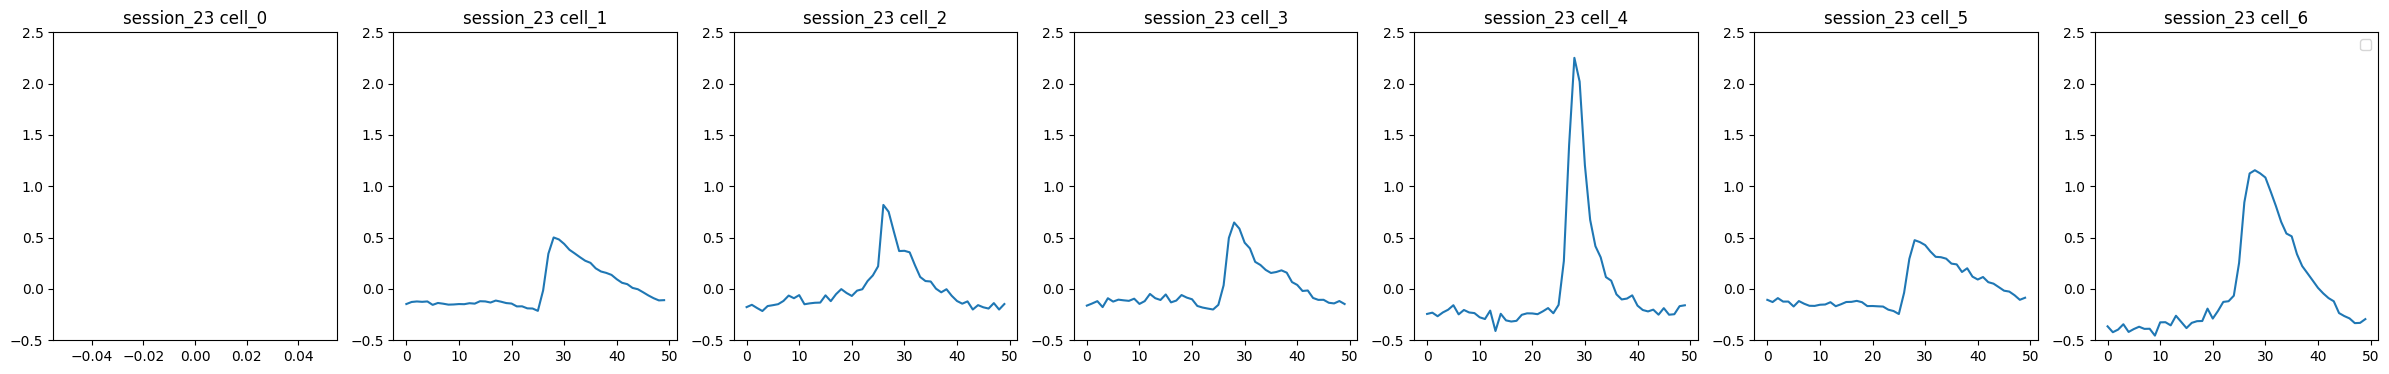

In [104]:
cell_list = []

for animal in clean_fixed_activity_dict_NDNF_newest:
    if animal == "animal_23":
        for cell in clean_fixed_activity_dict_NDNF_newest[animal]:
            cell_list.append(np.mean(clean_fixed_activity_dict_NDNF_newest[animal][cell], axis=1))

print(len(cell_list))

cell_array =np.array(cell_list)

overall_mean = np.mean(cell_array, axis=0)


fig, axs = plt.subplots(1, len(cell_list), figsize=(30,4))

for i in range(len(cell_list)):
    axs[i].plot(cell_list[i])
    axs[i].set_title(f"session_23 cell_{i}")
    axs[i].plot(overall_mean, color='k', linewidth=3)
    axs[i].set_ylim(-0.5, 2.5)
plt.legend()
plt.show()

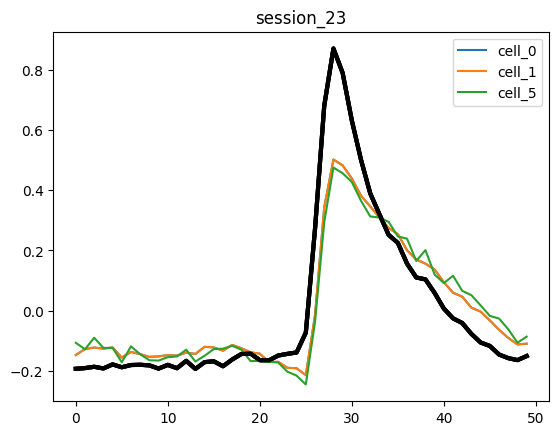

In [94]:
cells_of_interest_list = [0, 1, 5]
for i in range(len(cell_list)):
    if i in cells_of_interest_list:
        plt.plot(cell_list[i], label=f"cell_{i}")
        plt.plot(overall_mean, color='k', linewidth=3)
        plt.title("session_23")

plt.legend()
plt.show()

torch.Size([149, 176, 50])


Loss: 0.47138521584906734 : 100%|██████████| 4000/4000 [06:44<00:00,  9.88it/s]


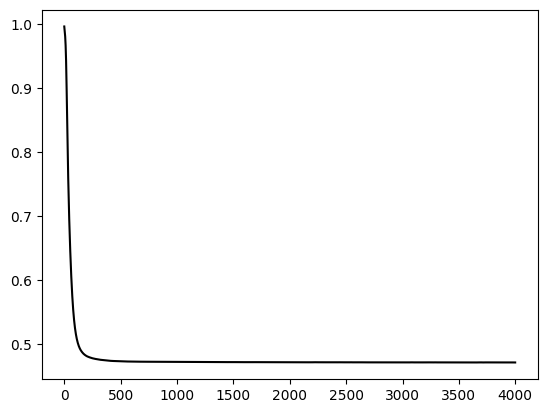

In [87]:

cued_clean_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(animal_clean_dict_activity):
    if idx > 28:
        cued_clean_activity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_clean_dict_activity[animal]



cue_model_20_raw_new_activity, example_cell_tensor_cue = get_the_tca_model(cued_clean_activity_dict_NDNF_newest, components=(0,20,0))


In [96]:

save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_cued_model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(cue_model_20_raw_new_activity, f)

In [126]:

cued_clean_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(animal_clean_dict_activity):
    if idx > 28:
        cued_clean_activity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_clean_dict_activity[animal]




example_cell_tensor_cue.shape torch.Size([149, 176, 50])
F.shape (20, 149, 50)  W.shape (20, 176)
X shape (mean over pos): (176, 20)


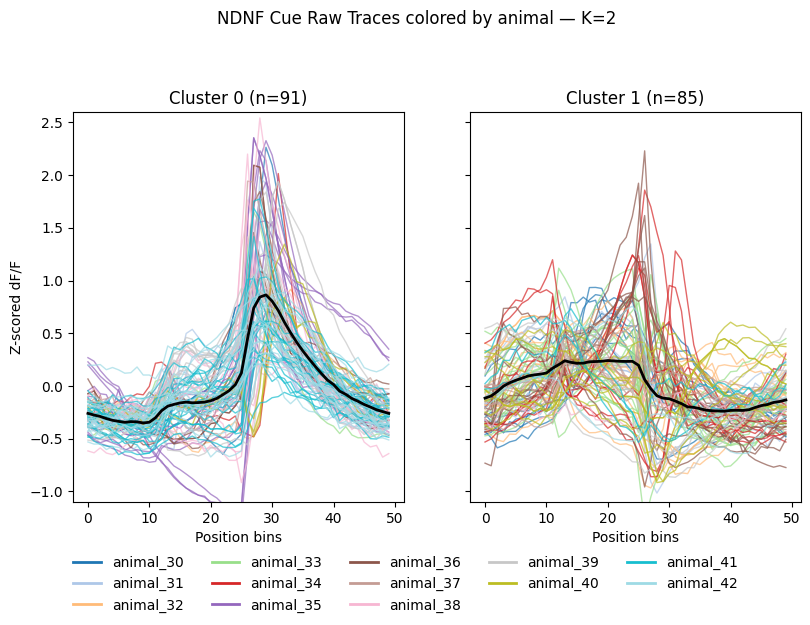

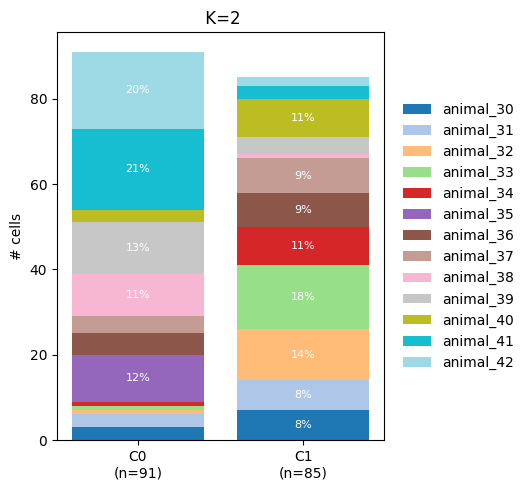

In [127]:

print(f"example_cell_tensor_cue.shape {example_cell_tensor_cue.shape}")


cue_labels_dict_raw_new = get_labels_all_different_Ks_single(cue_model_20_raw_new_activity, which_vectors=1)
cue_means_dict_raw_new = plot_reconstructions(cue_labels_dict_raw_new, cued_clean_activity_dict_NDNF_newest, prefix="NDNF Cue New")



K=2

cells_per_animal_dict = get_cells_per_animal_dict(cued_clean_activity_dict_NDNF_newest)
plot_cluster_traces_by_animal(cue_means_dict_raw_new,
                              cued_clean_activity_dict_NDNF_newest,
                              cells_per_animal_dict,
                              K=K,
                              ncol=5, spacing=0.2,
                              title_prefix="NDNF Cue Raw")

plot_cluster_animal_composition_stacked(cue_means_dict_raw_new, cells_per_animal_dict, K,
                                            title_prefix="", show_percent_labels=True)
